In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv('world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())

Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [29]:
import plotly.express as px
import plotly.graph_objects as go

print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


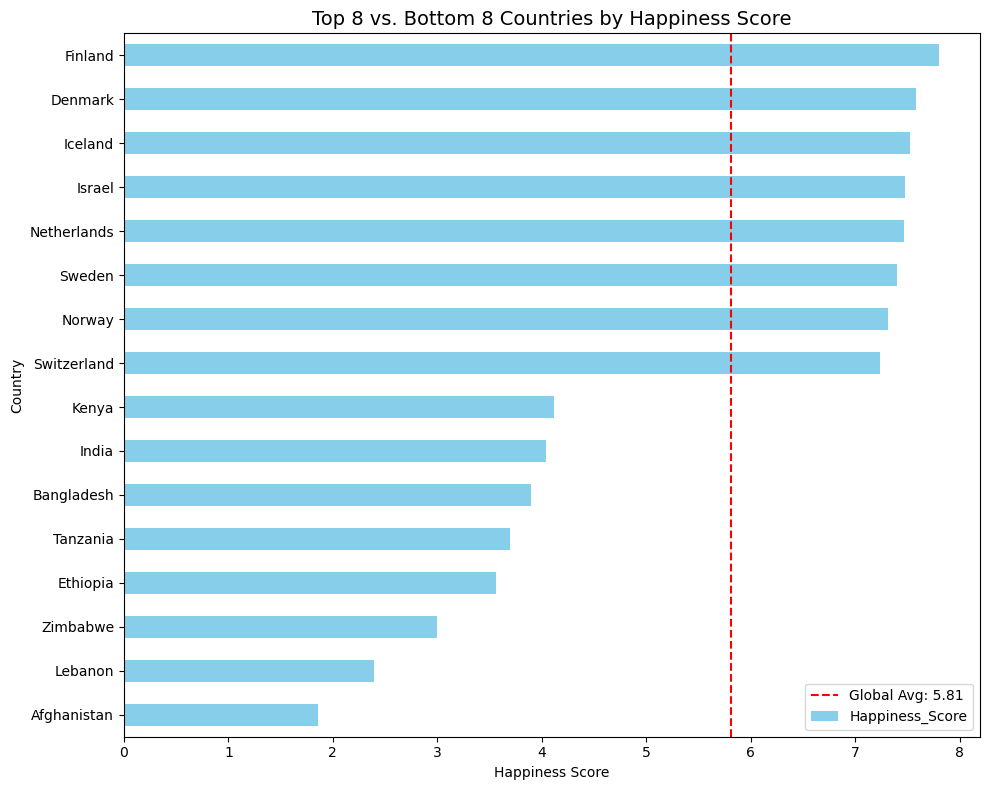

In [30]:
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)

import matplotlib.pyplot as plt
ax = combined.plot(kind='barh', x='Country', y='Happiness_Score', 
                   figsize=(10, 8), color='skyblue', legend=False)

plt.axvline(global_avg, color='red', linestyle='--', label=f'Global Avg: {global_avg:.2f}')
plt.title('Top 8 vs. Bottom 8 Countries by Happiness Score', fontsize=14)
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.legend()


plt.tight_layout()
plt.show()

Global average: 5.81


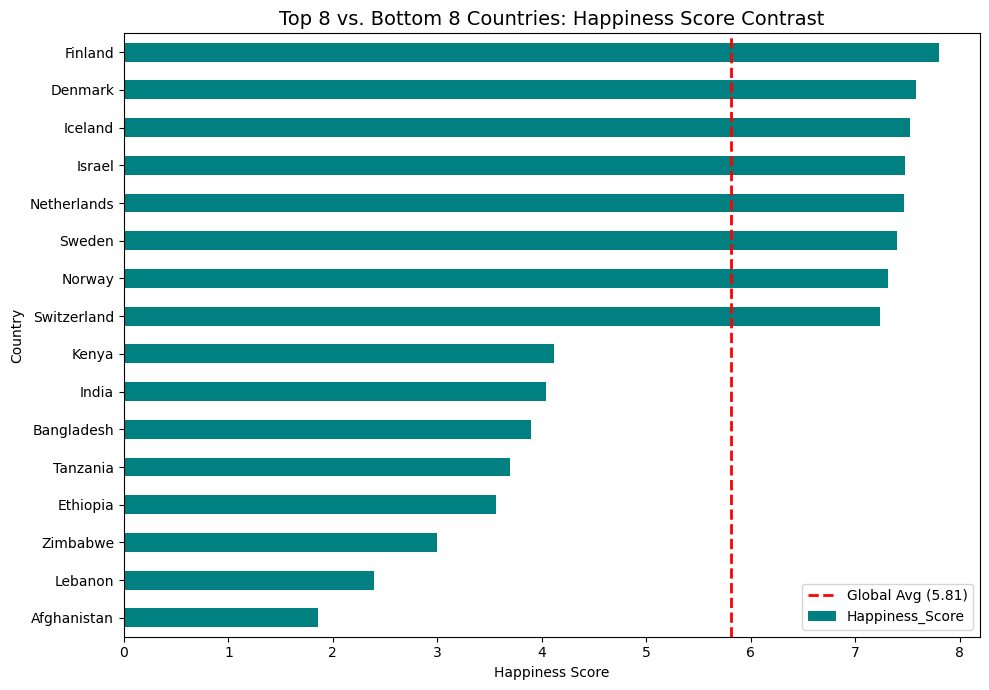

In [33]:
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")


import matplotlib.pyplot as plt


ax = combined.plot(
    kind='barh', 
    x='Country', 
    y='Happiness_Score', 
    figsize=(10, 7), 
    color='teal',
    legend=False
)

plt.axvline(global_avg, color='red', linestyle='--', linewidth=2, label=f'Global Avg ({global_avg:.2f})')


plt.title('Top 8 vs. Bottom 8 Countries: Happiness Score Contrast', fontsize=14)
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Regional Averages for GDP and Freedom:
                          GDP   Freedom
Region                                 
East Asia           10.312000  0.754000
South Asia           7.152250  0.546250
Sub-Saharan Africa   7.082000  0.599429
Western Europe      10.963533  0.896067


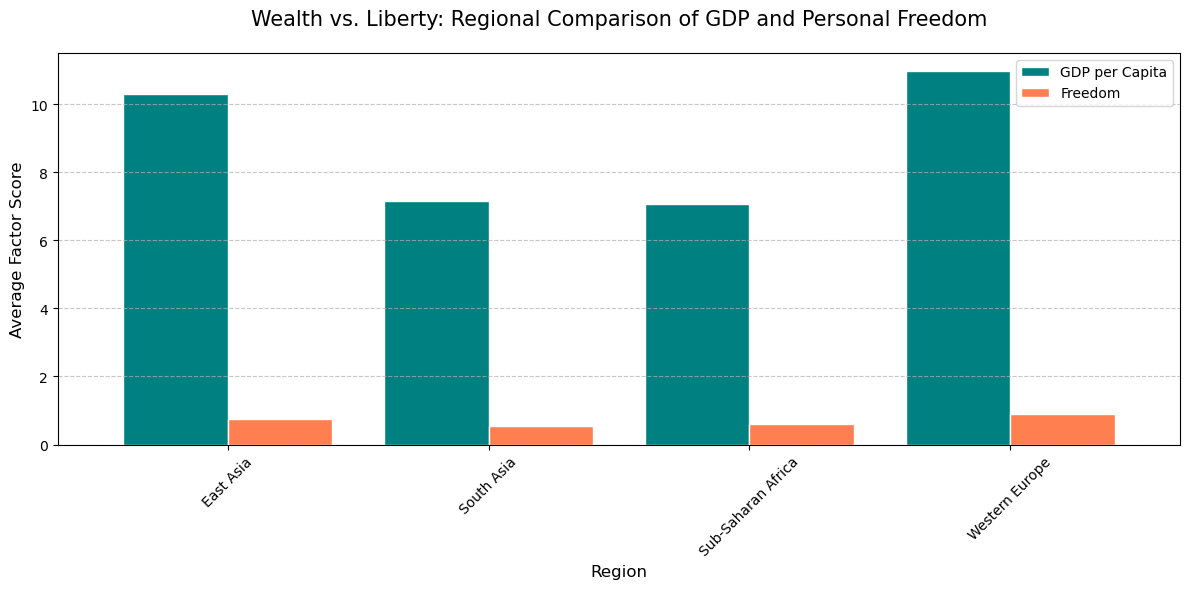

In [32]:
target_regions = ['Western Europe', 'Latin America', 'East Asia', 'Sub-Saharan Africa', 'South Asia']

gdp_col = [c for c in df.columns if 'gdp' in c.lower()][0]
freedom_col = [c for c in df.columns if 'freedom' in c.lower()][0]
columns_to_plot = [gdp_col, freedom_col]


stretch_data = (df[df['Region'].isin(target_regions)]
                .groupby('Region')[columns_to_plot]
                .mean())

print("Regional Averages for GDP and Freedom:")
print(stretch_data)


import matplotlib.pyplot as plt

colors = ['#008080', '#FF7F50']

ax = stretch_data.plot(
    kind='bar', 
    figsize=(12, 6), 
    color=colors, 
    edgecolor='white',
    width=0.8
)


plt.title('Wealth vs. Liberty: Regional Comparison of GDP and Personal Freedom', fontsize=15, pad=20)


plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Factor Score', fontsize=12)
plt.xticks(rotation=45) # Prevents region names from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds a subtle grid for better readability


plt.legend(['GDP per Capita', 'Freedom'], frameon=True)

plt.tight_layout()
plt.show()